In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
import os

# 1. Veri setini buluttan çek (KATE-CD)
print("Veri seti yükleniyor, biraz bekle knk...")
dataset = load_dataset("hkayabilisim/kate-cd")

# 2. Kayıt yollarını sisteme tanıt
img_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/images/'
mask_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/masks/'

# 3. Klasörler yoksa oluştur (Güvenlik önlemi)
os.makedirs(img_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# 4. Test için ilk 20 tanesini ayıklayalım
print("Resimler Drive'a aktarılıyor...")
for i, veri in enumerate(dataset['train']):
    if i == 20: break

    # Resim ve Maskeyi isim vererek Drive'a PNG olarak kaydet
    # Not: 'image' ve 'label' Hugging Face'deki standart sütun isimleridir
    veri['image'].save(f"{img_dir}deprem_{i}.png")
    veri['label'].save(f"{mask_dir}maske_{i}.png")

print(f"İşlem bitti! {img_dir} klasörüne git ve resimlerin gelip gelmediğini kontrol et.")

Veri seti yükleniyor, biraz bekle knk...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetNotFoundError: Dataset 'hkayabilisim/kate-cd' doesn't exist on the Hub or cannot be accessed.

In [ ]:
!pip install huggingface_hub
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from datasets import load_dataset
import os

# 1. Resmi veri setini yükle
print("Veri seti çekiliyor (CSCRS/kate-cd)...")
try:
    dataset = load_dataset("CSCRS/kate-cd")
except Exception as e:
    print(f"Hata: {e}. İsim 'hkayabilisim/kate-cd' ise onu da deneyelim.")
    dataset = load_dataset("hkayabilisim/kate-cd")

# 2. Kayıt yollarını sisteme tanıt
img_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/images/'
mask_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/masks/'

# Klasörleri tekrar kontrol et/oluştur
os.makedirs(img_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# 3. KATE-CD genelde pre_image, post_image ve label içerir.
# Bizim 'Tek Görüntü' planımız için 'post_earthquake' ve 'label' alacağız.
print("Resimler Drive'a fırlatılıyor...")

for i, veri in enumerate(dataset['train']):
    if i == 20: break # Önce 20 taneyle test ediyoruz

    # Sütun isimleri 'post_image' ve 'label' olabilir, kontrol ederek kaydediyoruz
    # Veri setinin yapısına göre burayı ufak revize edebiliriz:
    post_img = veri.get('post_image') or veri.get('image')
    label_img = veri.get('label') or veri.get('mask')

    if post_img and label_img:
        post_img.save(f"{img_dir}deprem_{i}.png")
        label_img.save(f"{mask_dir}maske_{i}.png")

print("Test bitti! Drive'da 'images' klasörüne bak bakalım.")

Veri seti çekiliyor (CSCRS/kate-cd)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/371M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/40.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/404 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/44 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38 [00:00<?, ? examples/s]

Resimler Drive'a fırlatılıyor...
Test bitti! Drive'da 'images' klasörüne bak bakalım.


In [ ]:
# DİKKAT: Bu işlem veri setinin büyüklüğüne göre 15-30 dakika sürebilir.
# Bağlantının kopmaması için Colab sekmesini kapatma.

print("Kemerleri bağla knk, tüm veri seti Drive'a taşınıyor...")

# 'if i == 20: break' satırını kaldırdık, böylece hepsini alacak.
for i, veri in enumerate(dataset['train']):
    # İlerleme durumunu görmek için her 100 resimde bir mesaj yazdıralım
    if i % 100 == 0:
        print(f"{i} adet resim işlendi...")

    post_img = veri.get('post_image') or veri.get('image')
    label_img = veri.get('label') or veri.get('mask')

    if post_img and label_img:
        post_img.save(f"{img_dir}deprem_{i}.png")
        label_img.save(f"{mask_dir}maske_{i}.png")

print(f"İşlem TAMAMLANDI! Toplam {i} adet resim ve maske Drive'ında.")

Kemerleri bağla knk, tüm veri seti Drive'a taşınıyor...
0 adet resim işlendi...
100 adet resim işlendi...
200 adet resim işlendi...
300 adet resim işlendi...
400 adet resim işlendi...
İşlem TAMAMLANDI! Toplam 403 adet resim ve maske Drive'ında.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# 1. Klasör yollarını tanımlıyoruz (Senin Drive yapına göre)
original_img_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/images/'
original_mask_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/masks/'

output_img_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/tiles/images/'
output_mask_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/tiles/masks/'

# Çıktı klasörleri yoksa otomatik oluşturulsun
os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

TILE_SIZE = 512  # SegFormer-B3 için en ideal parça boyutu
count = 0

print("🔪 Dilimleme işlemi başladı, sabırla bekle knk...")

# Resim listesini alıyoruz
img_list = sorted([f for f in os.listdir(original_img_dir) if f.endswith('.png')])

for img_name in tqdm(img_list):
    # Resim ve maskeyi okuyoruz
    img = cv2.imread(os.path.join(original_img_dir, img_name))

    # Maske isminin resim ismiyle uyumlu olduğundan emin ol (Örn: deprem_0.png -> maske_0.png)
    mask_name = img_name.replace('deprem', 'maske')
    mask = cv2.imread(os.path.join(original_mask_dir, mask_name), 0) # Gri tonlamalı oku

    if img is None or mask is None:
        continue

    h, w, _ = img.shape

    # Görüntüyü 512x512 piksellik karelere bölerek geziyoruz
    for y in range(0, h - TILE_SIZE + 1, TILE_SIZE):
        for x in range(0, w - TILE_SIZE + 1, TILE_SIZE):
            tile_img = img[y:y+TILE_SIZE, x:x+TILE_SIZE]
            tile_mask = mask[y:y+TILE_SIZE, x:x+TILE_SIZE]

            # Oluşan parçaları yeni isimlerle kaydediyoruz
            cv2.imwrite(f"{output_img_dir}tile_{count}.png", tile_img)
            cv2.imwrite(f"{output_mask_dir}tile_{count}.png", tile_mask)
            count += 1

print(f"\n✅ İşlem bitti! Toplam {count} adet parça (tile) oluşturuldu.")

🔪 Dilimleme işlemi başladı, sabırla bekle knk...


100%|██████████| 404/404 [00:40<00:00,  9.93it/s]


✅ İşlem bitti! Toplam 404 adet parça (tile) oluşturuldu.


In [ ]:
import os
from sklearn.model_selection import train_test_split

# 1. Parçalanmış resimlerin listesini alalım
tile_img_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/tiles/images/'
all_tiles = sorted(os.listdir(tile_img_dir))

# 2. Veriyi %80 Eğitim, %20 Doğrulama (Validation) olarak bölelim
train_files, val_files = train_test_split(all_tiles, test_size=0.2, random_state=42)

print(f"Eğitim için {len(train_files)} resim ayrıldı.")
print(f"Test/Doğrulama için {len(val_files)} resim ayrıldı.")


Eğitim için 323 resim ayrıldı.
Test/Doğrulama için 81 resim ayrıldı.


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os

class DepremDataset(Dataset):
    def __init__(self, file_list, img_dir, mask_dir, transform=None):
        self.file_list = file_list
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        # 1. Resim ve Maske yollarını çekiyoruz
        img_name = self.file_list[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # 2. Dosyaları okuyoruz
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Renkleri düzeltiyoruz
        mask = cv2.imread(mask_path, 0) # Maskeyi siyah-beyaz okuyoruz

        # 3. Maskeyi ikili (binary) hale getiriyoruz
        # 0: Sağlam alan/Arkaplan, 1: Enkaz/Hasarlı Yapı
        mask = np.where(mask > 0, 1, 0).astype(np.float32)

        # 4. PyTorch'un sevdiği format olan Tensor'a çeviriyoruz
        # Resmi [0, 1] arasına çekiyoruz (Normalizasyon)
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()

        return image, mask

print("✅ Dataset sınıfı hazır! Artık modelin 'gözleri' açık.")

✅ Dataset sınıfı hazır! Artık modelin 'gözleri' açık.


In [ ]:
from torch.utils.data import DataLoader

# --- EKSİK OLAN ADRESLERİ TANIMLIYORUZ ---
tile_img_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/tiles/images/'
tile_mask_dir = '/content/drive/MyDrive/Deprem_Yol_Analizi/data/tiles/masks/'

# 1. Dataset objelerini oluşturuyoruz
# Not: train_files ve val_files değişkenlerinin tanımlı olduğundan emin ol
train_dataset = DepremDataset(train_files, tile_img_dir, tile_mask_dir)
val_dataset = DepremDataset(val_files, tile_img_dir, tile_mask_dir)

# 2. DataLoader'ları tanımlıyoruz
# batch_size=4, T4 GPU için başlangıçta en güvenli değerdir
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print("✅ DataLoader'lar hazır. Artık model resimleri grup grup okuyabilir!")

✅ DataLoader'lar hazır. Artık model resimleri grup grup okuyabilir!


In [ ]:
import segmentation_models_pytorch as smp

# SegFormer-B3 mimarisini kuruyoruz (Encoder: mit_b3)
model = smp.Segformer(
    encoder_name="mit_b3",        # Daha yüksek öğrenme kapasitesi için B3
    encoder_weights="imagenet",   # Önceden öğrenilmiş görsel özellikleri kullan
    in_channels=3,                # RGB resim (3 kanal)
    classes=1,                    # Tek sınıf: Enkaz var/yok (Binary)
)

# Modeli GPU'ya gönderiyoruz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"🚀 SegFormer-B3 modeli {device} üzerinde göreve hazır!")

ModuleNotFoundError: No module named 'segmentation_models_pytorch'

In [ ]:
# 1. Eksik olan kütüphaneyi yüklüyoruz
!pip install segmentation-models-pytorch

# 2. Eğer diğerleri de silindiyse garantiye alalım (Hızlı iner)
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.8 MB/s eta 0:00:00


In [ ]:
import torch
import segmentation_models_pytorch as smp

# SegFormer-B3 mimarisini kuruyoruz
model = smp.Segformer(
    encoder_name="mit_b3",        # Daha yüksek kapasiteli B3 modeli
    encoder_weights="imagenet",   # Önceden öğrenilmiş görsel zeka
    in_channels=3,                # RGB resim
    classes=1,                    # Tek sınıf: Enkaz var/yok
)

# Modeli GPU'ya (T4) gönderiyoruz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"🚀 SegFormer-B3 modeli {device} üzerinde göreve hazır!")

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

🚀 SegFormer-B3 modeli cuda üzerinde göreve hazır!


In [ ]:
import torch.optim as optim
import segmentation_models_pytorch as smp

# 1. Kayıp Fonksiyonu: Dice Loss (Dengesiz veri setlerinde enkazı kaçırmamak için idealdir)
criterion = smp.losses.DiceLoss(mode='binary')

# 2. Optimizer: AdamW (Transformer modelleri için en dengeli öğrenme hızı)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

print("⚖️ Kayıp fonksiyonu ve Optimizer ayarlandı. Model artık hatasını nasıl düzelteceğini biliyor.")

⚖️ Kayıp fonksiyonu ve Optimizer ayarlandı. Model artık hatasını nasıl düzelteceğini biliyor.


In [ ]:
import torch
from tqdm import tqdm

# Ayarlar
epochs = 15 # Şimdilik 15 tur dönelim, duruma göre artırırız
best_loss = float('inf')
save_path = '/content/drive/MyDrive/Deprem_Yol_Analizi/models/en_iyi_model.pth'

print(f"🔥 Eğitim başlıyor! {epochs} tur boyunca model KATE-CD verilerini ezberlemeye çalışacak...")

for epoch in range(epochs):
    # --- EĞİTİM AŞAMASI ---
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    # --- DOĞRULAMA (VALIDATION) AŞAMASI ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device).unsqueeze(1).float()
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"👉 Epoch {epoch+1} Sonucu: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # En iyi modeli Drive'a kaydet (Checkpoint)
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"✨ Yeni en iyi model Drive'a kaydedildi: {save_path}")

print("\n🎉 EĞİTİM TAMAMLANDI! Artık 6 Şubat enkazlarını tanıyan bir yapay zekaya sahipsin.")

🔥 Eğitim başlıyor! 15 tur boyunca model KATE-CD verilerini ezberlemeye çalışacak...


Epoch 1/15 [Train]: 100%|██████████| 81/81 [00:59<00:00,  1.37it/s, loss=0.354]


👉 Epoch 1 Sonucu: Train Loss: 0.1862 | Val Loss: 0.4229
✨ Yeni en iyi model Drive'a kaydedildi: /content/drive/MyDrive/Deprem_Yol_Analizi/models/en_iyi_model.pth


Epoch 2/15 [Train]: 100%|██████████| 81/81 [01:03<00:00,  1.28it/s, loss=0.209]


👉 Epoch 2 Sonucu: Train Loss: 0.1578 | Val Loss: 0.4198
✨ Yeni en iyi model Drive'a kaydedildi: /content/drive/MyDrive/Deprem_Yol_Analizi/models/en_iyi_model.pth


...

👉 Epoch 13 Sonucu: Train Loss: 0.1053 | Val Loss: 0.4107


Epoch 14/15 [Train]: 100%|██████████| 81/81 [00:58<00:00,  1.38it/s, loss=0.0728]


👉 Epoch 14 Sonucu: Train Loss: 0.1039 | Val Loss: 0.4091


Epoch 15/15 [Train]: 100%|██████████| 81/81 [00:59<00:00,  1.37it/s, loss=0.0655]


👉 Epoch 15 Sonucu: Train Loss: 0.1020 | Val Loss: 0.4426

🎉 EĞİTİM TAMAMLANDI! Artık 6 Şubat enkazlarını tanıyan bir yapay zekaya sahipsin.


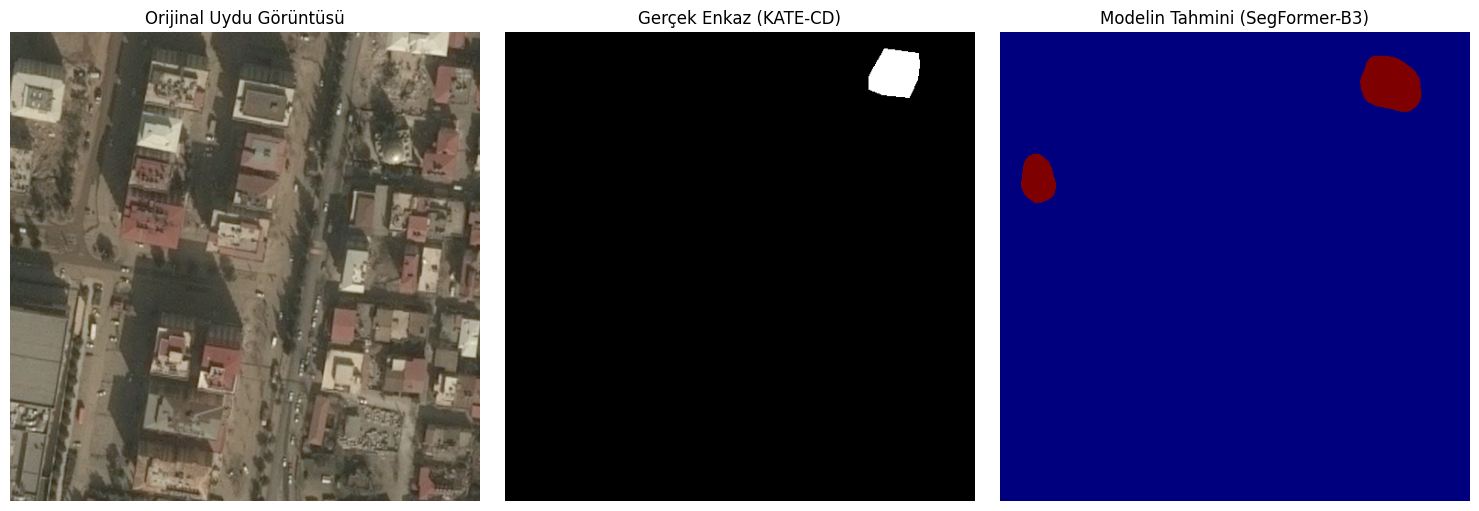

Hocam 50 numaralı resim için sonuçlar yukarıda. Nasıl görünüyor?


In [ ]:
import matplotlib.pyplot as plt
import random

# 1. En iyi ağırlıkları yükleyelim (Garanti olsun)
model.load_state_dict(torch.load('/content/drive/MyDrive/Deprem_Yol_Analizi/models/en_iyi_model.pth'))
model.eval()

# 2. Rastgele bir test resmi seçelim
idx = random.randint(0, len(val_dataset)-1)
image, mask = val_dataset[idx]

# 3. Tahmin yürütelim
with torch.no_grad():
    input_img = image.unsqueeze(0).to(device)
    output = model(input_img)
    # Sigmoid ile olasılığa çevir ve 0.5 eşiğiyle maskele
    pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
    pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)

# 4. GÖRSELLEŞTİRME
plt.figure(figsize=(15, 5))

# Orijinal Uydu Görüntüsü
plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0).cpu().numpy())
plt.title("Orijinal Uydu Görüntüsü")
plt.axis('off')

# Gerçek Enkaz (Ground Truth)
plt.subplot(1, 3, 2)
plt.imshow(mask.cpu().numpy(), cmap='gray')
plt.title("Gerçek Enkaz (KATE-CD)")
plt.axis('off')

# Modelin Tahmini
plt.subplot(1, 3, 3)
plt.imshow(pred_mask_binary, cmap='jet') # Enkaz bölgeleri renkli gözüksün
plt.title("Modelin Tahmini (SegFormer-B3)")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Hocam {idx} numaralı resim için sonuçlar yukarıda. Nasıl görünüyor?")

In [ ]:
model.eval()
ious = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model(images)

        # KRİTİK NOKTA: Sadece kanal boyutunu (1. boyut) atıyoruz
        # preds boyutu [Batch, 512, 512] kalmalı
        preds = (torch.sigmoid(outputs) > 0.5).squeeze(1).cpu().numpy()
        masks_np = masks.cpu().numpy()

        # Batch içindeki resim sayısı kadar dön
        for i in range(preds.shape[0]):
            score = calculate_iou(preds[i], masks_np[i])
            ious.append(score)

print(f"🏆 Düzeltilmiş Ortalama IoU: %{np.mean(ious)*100:.2f}")

NameError: name 'val_loader' is not defined

In [ ]:
import albumentations as A

# Uydu görüntüleri için en etkili artırma yöntemleri
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.9),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.9),
    ], p=0.3),
])

# Test/Validation setine dokunmuyoruz, onlar orijinal kalmalı

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # ShiftScaleRotate yerine Affine kullanıyoruz
    A.Affine(translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
             scale=(0.95, 1.05),
             rotate=(-15, 15),
             p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

In [ ]:
# Train datasetini transform ile yeniden oluşturuyoruz
train_dataset = DepremDataset(train_files, tile_img_dir, tile_mask_dir, transform=train_transform)

# DataLoader'ı yeniden kuruyoruz
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

print("✅ Veri artırma (Augmentation) motoru çalıştırıldı.")

✅ Veri artırma (Augmentation) motoru çalıştırıldı.


In [ ]:
# Önce modeli temiz bir şekilde GPU'ya alalım
model.load_state_dict(torch.load('/content/drive/MyDrive/Deprem_Yol_Analizi/models/en_iyi_model.pth'))
model.to(device)

# Öğrenme hızını biraz düşürelim ki model "ince ayar" yapabilsin
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)

print("🧠 %43.17'lik tecrübe yüklendi, model yeni idmana hazır!")

🧠 %43.17'lik tecrübe yüklendi, model yeni idmana hazır!


In [ ]:
!pip install segmentation-models-pytorch osmnx geopandas shapely rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 12.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import torch
import segmentation_models_pytorch as smp

drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modeli tanımla (Dünkü mimariyle aynı olmalı)
model = smp.Segformer(encoder_name="mit_b3", encoder_weights=None, in_channels=3, classes=1).to(device)

# Ağırlıkları yükle
model.load_state_dict(torch.load('/content/drive/MyDrive/Deprem_Yol_Analizi/models/en_iyi_model.pth'))
model.eval()
print("✅ Model ve Drive hazır, hocam!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model ve Drive hazır, hocam!


🌐 Yol verileri OpenStreetMap'ten çekiliyor...


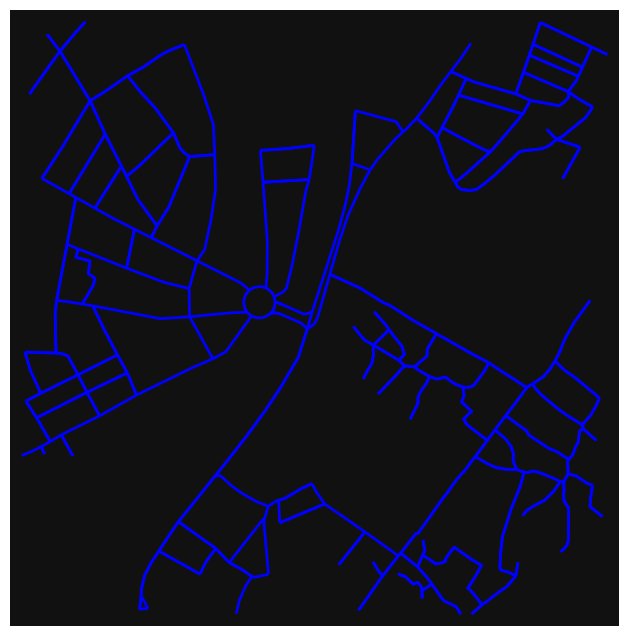

✅ Haritadaki yolların iskeletini çıkardık!


In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

# 1. Analiz etmek istediğimiz noktanın koordinatları (Örn: Antakya merkezi bir nokta)
# Sen kendi uydu resminin koordinatlarını bulunca burayı değiştireceğiz.
merkez_nokta = (36.2023, 36.1613)

# 2. Bu noktanın etrafındaki 500 metrelik alandaki yolları çekelim
# network_type="drive" diyerek sadece araba yollarını alıyoruz.
print("🌐 Yol verileri OpenStreetMap'ten çekiliyor...")
yol_grafi = ox.graph_from_point(merkez_nokta, dist=500, network_type="drive")

# 3. Çektiğimiz yolları görselleştirelim
fig, ax = ox.plot_graph(yol_grafi, node_size=0, edge_color="blue", edge_linewidth=2)
plt.show()

print("✅ Haritadaki yolların iskeletini çıkardık!")

In [ ]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import box, Polygon

# 1. Senaryo için bir merkez koordinat seçiyoruz (Antakya)
# Bu koordinatları gerçek bir sistemde uydu görüntüsünün metadata'sından alacaktık.
enlem, boylam = 36.2023, 36.1613

# 2. Resmimizin dünyada kapladığı alanı hesaplayalım.
# KATE-CD çözünürlüğü ~0.5m olduğu için 512 piksel yaklaşık 256 metredir.
alan_genisligi_derece = 0.0023 # Yaklaşık 250 metreye tekabül eder (enlemde)

# Bir 'Bounding Box' (Sınır Kutusu) oluşturalım
min_lat, max_lat = enlem - alan_genisligi_derece/2, enlem + alan_genisligi_derece/2
min_lon, max_lon = boylam - alan_genisligi_derece/2, boylam + alan_genisligi_derece/2

print(f"✅ Analiz Alanı Tanımlandı: {enlem}, {boylam}")

✅ Analiz Alanı Tanımlandı: 36.2023, 36.1613
